In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
EXPS_TITLE = 'SW'
EXPS = [
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER_proc_imitation"),
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER_proc"),
    # os.path.join("experiments", "MC", "FINDER", "SW_FINDER_proc_imitation"),
    # os.path.join("experiments", "MC", "FINDER", "SW_FINDER_proc"),
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER"),
    # os.path.join("experiments", "DQN", "FINDER", "ORIGINAL_SW_FINDER"),
    # os.path.join("experiments", "MC", "FINDER", "SW_FINDER_proc_SingleLevel"),
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER_proc_ones_SingleLevel"),
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER_proc_SingleLevel"),
    # os.path.join("experiments", "DQN", "FINDER", "SW_FINDER_proc_noNorm_ones_SingleLevel"),

    # all folder in experiments/MEGA_integration/
    os.path.join("experiments", "MEGA_integration", s) for s in os.listdir(os.path.join("experiments", "MEGA_integration"))



]

EXP_LABELS = [
    # "DQN SW_FINDER_proc_imitation",
    # "DQN SW_FINDER_proc",
    # "MC SW_FINDER_proc_imitation",
    # "MC SW_FINDER_proc",
    # "DQN SW_FINDER",
    # "DQN ORIGINAL_SW_FINDER",
    # "MC SW_FINDER_proc_SingleLevel",
    # "DQN SW_FINDER_proc_ones_SingleLevel",
    # "DQN SW_FINDER_proc_SingleLevel",
    # "DQN SW_FINDER_proc_noNorm_ones_SingleLevel",

    s for s in os.listdir(os.path.join("experiments", "MEGA_integration"))

]


# EXPS_TITLE = 'BA'
# EXPS = [
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER_proc_imitation"),
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER_proc"),
#     os.path.join("experiments", "MC", "FINDER", "BA_FINDER_proc_imitation"),
#     os.path.join("experiments", "MC", "FINDER", "BA_FINDER_proc"),
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER"),
#     os.path.join("experiments", "DQN", "FINDER", "ORIGINAL_BA_FINDER"),
#     os.path.join("experiments", "MC", "FINDER", "BA_FINDER_proc_SingleLevel"),
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER_proc_ones_SingleLevel"),
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER_proc_SingleLevel"),
#     os.path.join("experiments", "DQN", "FINDER", "BA_FINDER_proc_noNorm_ones_SingleLevel"),


# ]

# EXP_LABELS = [
#     "DQN BA_FINDER_proc_imitation",
#     "DQN BA_FINDER_proc",
#     "MC BA_FINDER_proc_imitation",
#     "MC BA_FINDER_proc",
#     "DQN BA_FINDER",
#     "DQN ORIGINAL_BA_FINDER",
#     "MC BA_FINDER_proc_SingleLevel",
#     "DQN BA_FINDER_proc_ones_SingleLevel",
#     "DQN BA_FINDER_proc_SingleLevel",
#     "DQN BA_FINDER_proc_noNorm_ones_SingleLevel",
# ]




COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']


In [3]:
def find_best_model_path(exp_path):
    levels_dir = os.path.join(exp_path, "levels")
    best_model_path = None
    best_vc = float('inf')

    best_level = None
    best_iter = None
    recorded_vc = float('inf')

    for level_dir in os.listdir(levels_dir):
        level_log_path = os.path.join(levels_dir, level_dir, "level_log.json")
        with open(level_log_path, "r") as f:
            level_log = json.load(f)

        for entry in level_log['checkpoint_vcs']:
            if entry['vc'] < best_vc:
                best_vc = entry['vc']
                best_model_path = os.path.join(levels_dir, level_dir, "models", f"model_iter_{entry['iteration']}.ckpt")

                best_level = level_dir
                best_iter = entry['iteration']
                recorded_vc = entry['vc']

    print(f"Best model level: {best_level}, best iter: {best_iter}, recorded vc: {recorded_vc}")
    return best_model_path

def find_best_iter_levels(exp_path):
    """
    Find the best validation score (VC), its iteration, and corresponding level for each level in the experiment.
    
    Args:
        exp_path (str): Path to the experiment directory
        
    Returns:
        list[dict]: List of dictionaries containing best metrics for each level
    """
    results = []
    num_levels = len(os.listdir(os.path.join(exp_path, "levels")))
    
    iter_offset = 0
    for l in range(num_levels):
        _key = f'level_{l}'
        level_log_path = os.path.join(exp_path, "levels", _key, "level_log.json")
        
        with open(level_log_path, "r") as f:
            level_log = json.load(f)

        checkpoint_iters = {entry['iteration'] for entry in level_log['checkpoint_vcs']}

        # Get scores for this level only
        level_scores = [(iter_offset + score['iteration'], score['vc']) 
                        for score in level_log['validation_scores'] 
                        if score['iteration'] in checkpoint_iters]
        level_scores = np.array(level_scores)
        
        # Find best metrics for this level
        min_vc = np.min(level_scores[:, 1])
        min_vc_iter = level_scores[np.argmin(level_scores[:, 1]), 0]
        
        results.append({
            'level': l,
            'best_vc': min_vc,
            'best_iter': int(min_vc_iter),
            'best_level_iter': int(min_vc_iter) - iter_offset,
            'iter_offset': iter_offset
        })
        
        iter_offset += level_log['training_iterations'][-1]['iteration']
    
    return results

level_0
level cutoffs:  {0: 100000}
level_0
level cutoffs:  {0: 100000}
level_0
level cutoffs:  {0: 100000}
level_0
level cutoffs:  {0: 100000}
level_0
level cutoffs:  {0: 100000}
level_0
level cutoffs:  {0: 100000}


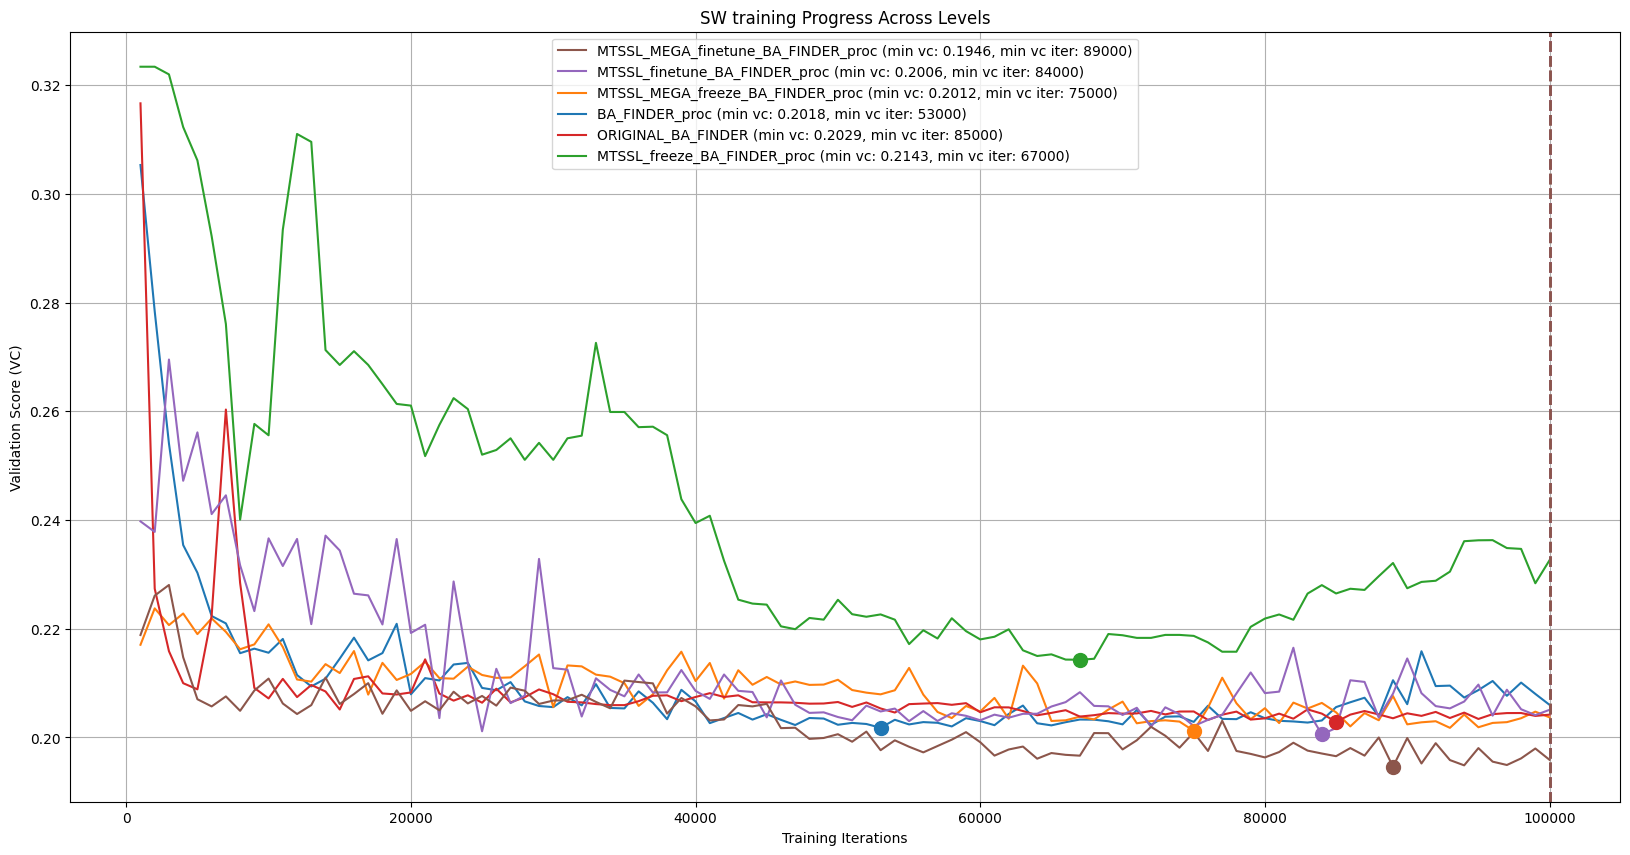

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Lists to store lines, labels, and min_vc values
lines = []
labels = []
min_vcs = []

for exp_i, exp_path in enumerate(EXPS):
    with open(os.path.join(exp_path, "training_log.json"), "r") as f:
        training_log = json.load(f)

    curr_color = COLORS[exp_i]
    num_levels = len(os.listdir(os.path.join(exp_path, "levels")))
    
    vc_scores = []
    iter_offset = 0
    levels_cutoffs = {}
    for l in range(num_levels):
        _key = f'level_{l}'
        print(_key)
        level_log_path = os.path.join(exp_path, "levels", _key, "level_log.json")
        with open(level_log_path, "r") as f:
            level_log = json.load(f)

        checkpoint_iters = {entry['iteration'] for entry in level_log['checkpoint_vcs']}

        level_val_scores_dict = [
            (iter_offset + score['iteration'], score['vc'])
            for score in level_log['validation_scores']
            if score['iteration'] in checkpoint_iters
        ]
        iter_offset += level_log['training_iterations'][-1]['iteration']
        levels_cutoffs[l] = iter_offset
        vc_scores.extend(level_val_scores_dict)

    vc_scores = np.array(vc_scores)
    min_vc = np.min(vc_scores[:, 1])
    min_vc_iter = vc_scores[np.argmin(vc_scores[:, 1]), 0]
    
    # Store min_vc and labels
    min_vcs.append(min_vc)
    label = f"{EXP_LABELS[exp_i]} (min vc: {min_vc:.4f}, min vc iter: {int(min_vc_iter)})"
    labels.append(label)
    
    # Plot and collect line objects
    line, = ax.plot(vc_scores[:, 0], vc_scores[:, 1], label=label, color=curr_color)
    lines.append(line)
    ax.scatter(min_vc_iter, min_vc, color=curr_color, s=100, marker='o', zorder=5)

    print("level cutoffs: ", levels_cutoffs)
    # Add vertical lines for level transitions
    for level, cutoff in levels_cutoffs.items():
        ax.axvline(x=cutoff, color=curr_color, linestyle='--', alpha=1, linewidth=2)

# Now sort lines, labels, and min_vcs based on min_vc
sorted_indices = np.argsort(min_vcs)
sorted_lines = [lines[i] for i in sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]

ax.set_xlabel('Training Iterations')
ax.set_ylabel('Validation Score (VC)')
ax.legend(sorted_lines, sorted_labels)
ax.grid(True)
plt.title(f'{EXPS_TITLE} training Progress Across Levels')
plt.show()

In [5]:
for exp_path in EXPS:
    print(f"\nAnalyzing {exp_path}:")
    level_results = find_best_iter_levels(exp_path)
    best_model_path = find_best_model_path(exp_path)
    for result in level_results:
        print(f"Level {result['level']}: Best VC = {result['best_vc']:.4f} "
              f"at iteration {result['best_iter']} (level iter: {result['best_level_iter']})")



Analyzing experiments/MEGA_integration/BA_FINDER_proc:
Best model level: level_0, best iter: 53000, recorded vc: 0.20176761383948943
Level 0: Best VC = 0.2018 at iteration 53000 (level iter: 53000)

Analyzing experiments/MEGA_integration/MTSSL_MEGA_freeze_BA_FINDER_proc:
Best model level: level_0, best iter: 75000, recorded vc: 0.2012085575888729
Level 0: Best VC = 0.2012 at iteration 75000 (level iter: 75000)

Analyzing experiments/MEGA_integration/MTSSL_freeze_BA_FINDER_proc:
Best model level: level_0, best iter: 67000, recorded vc: 0.21428133496593493
Level 0: Best VC = 0.2143 at iteration 67000 (level iter: 67000)

Analyzing experiments/MEGA_integration/ORIGINAL_BA_FINDER:
Best model level: level_0, best iter: 85000, recorded vc: 0.2028541682651794
Level 0: Best VC = 0.2029 at iteration 85000 (level iter: 85000)

Analyzing experiments/MEGA_integration/MTSSL_finetune_BA_FINDER_proc:
Best model level: level_0, best iter: 84000, recorded vc: 0.200552942184416
Level 0: Best VC = 0.200